# Netflix Catalog - Exploratory Data Analysis 🎬

## Project goal

The main goal of this project is to explore the structure of the Netflix catalog, identify trends and analyze movies/tv shows.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/clean_netflix_titles.csv")

## 01. Distribution of content types



In [4]:
type_counts = df['type'].value_counts()
type_counts

type
movie      6131
tv_show    2676
Name: count, dtype: int64

In [5]:
type_in_percentage = type_counts * 100 / len(df)
type_in_percentage.round(2)

type
movie      69.62
tv_show    30.38
Name: count, dtype: float64

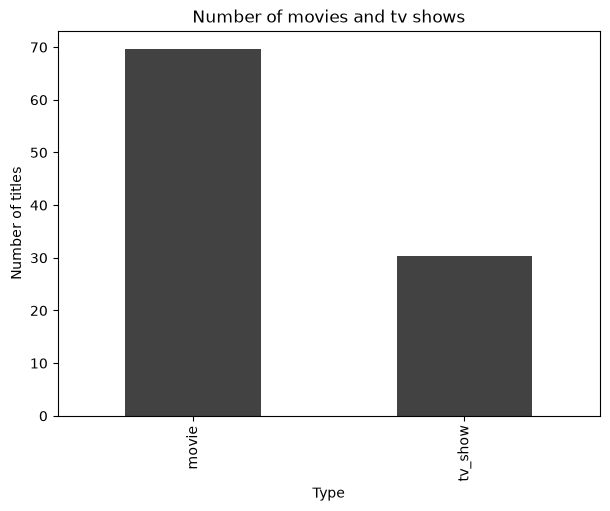

In [6]:
type_in_percentage.plot(kind='bar', figsize=(7, 5), color='#424242')

plt.title("Number of movies and tv shows")
plt.xlabel("Type")
plt.ylabel("Number of titles")

plt.show()

### FInding

Movies are approximately **70%** of the analyzed catalog, while TV shows is **30%**. The dataset contains more thank twice as many mowies as TV shows

## 02. Content over time


In [7]:
titles_by_year = (
    df["year_added"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

titles_by_year

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      10
2014      23
2015      73
2016     418
2017    1164
2018    1625
2019    1999
2020    1878
2021    1498
Name: count, dtype: int64

In [8]:
percentage_by_year = (titles_by_year * 100 / titles_by_year.sum()).round(2)

yearly_summary = pd.DataFrame({
    "title_by_year": titles_by_year,
    "percentage_by_year": percentage_by_year
})


In [9]:
yearly_summary


,title_by_year,percentage_by_year
year_added,,
2008,2,0.02
2009,2,0.02
2010,1,0.01
2011,13,0.15
2012,3,0.03
2013,10,0.11
2014,23,0.26
2015,73,0.84
2016,418,4.80


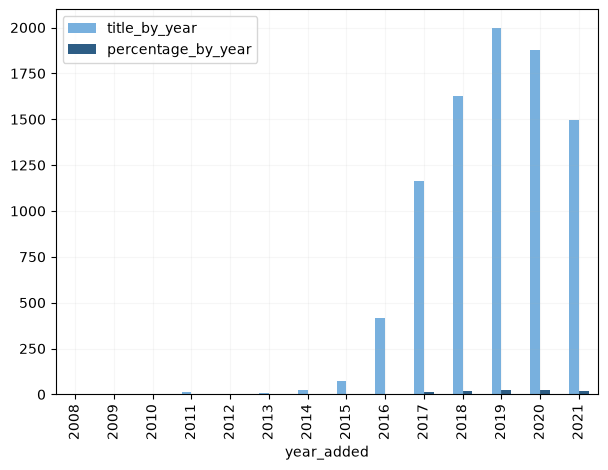

In [10]:
yearly_summary.plot(kind='bar', figsize=(7, 5), color=['#78b0de', '#2d5d85'], alpha=1.0)

plt.grid(alpha=0.1)

plt.show()

In [11]:
diff = titles_by_year.diff()
last_year = titles_by_year - diff
yearly_percentage_change = (diff / last_year * 100).round(2)
yearly_percentage_change

year_added
2008        NaN
2009       0.00
2010     -50.00
2011    1200.00
2012     -76.92
2013     233.33
2014     130.00
2015     217.39
2016     472.60
2017     178.47
2018      39.60
2019      23.02
2020      -6.05
2021     -20.23
Name: count, dtype: float64

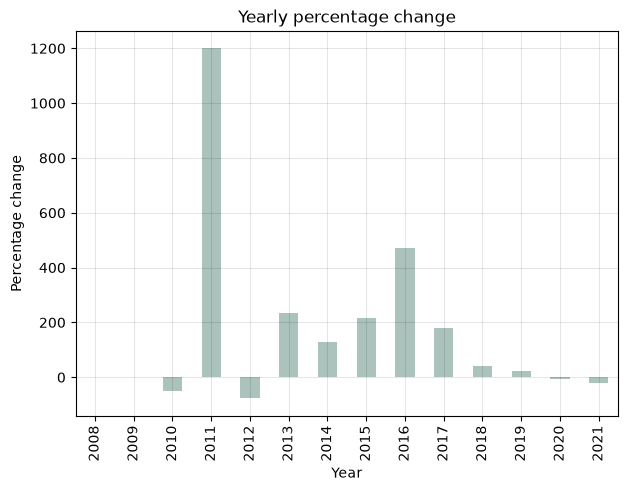

In [12]:
yearly_percentage_change.plot(kind='bar', figsize=(7, 5), color='#abc2bd', alpha=1.0)

plt.title("Yearly percentage change")
plt.xlabel("Year")
plt.ylabel("Percentage change")

plt.grid(alpha=0.1,color='k')

plt.show()

### Finding

The amount of content added to the Netflix platform grew at a very rapid pace over the years. The peak was reached in 2019, when 1,999 titles were added, accounting for almost 23% of the entire analyzed catalog. Interestingly, a reversal of this trend can be observed in 2020 and 2021 — the number of new titles began to decline, recording a negative percentage change (approximately -6% in 2020 and -20% in 2021)

## 3. Age of productions

In [13]:
age_data = df.dropna(subset=['age_of_show'])

In [15]:
age_summary = age_data['age_of_show'].agg(['count', 'mean', 'median', 'min', 'max']).round(2)
age_summary

count     8695.0
mean         4.7
median       1.0
min          0.0
max         93.0
Name: age_of_show, dtype: float64

In [16]:
age_data['age_of_show'].describe()

count    8695.000000
mean        4.700403
std         8.796060
min         0.000000
25%         0.000000
50%         1.000000
75%         5.000000
max        93.000000
Name: age_of_show, dtype: float64

In [19]:
age_by_type = age_data.groupby('type')['age_of_show'].agg(['count', 'mean', 'median', 'min', 'max']).round(2)

age_by_type

,count,mean,median,min,max
type,,,,,
movie,6129,5.73,2.0,0.0,75.0
tv_show,2566,2.24,0.0,0.0,93.0


## 4. Movie duration

In [34]:
movies = df[(df['type'] == "movie") & df['movie_duration_min'].notna()]
print(len(movies))

6128


In [40]:
movie_duration_summary = movies['movie_duration_min'].agg(['count', 'mean', 'median', 'min', 'max']).round(2)

movie_duration_summary

count     6128.00
mean        99.58
median      98.00
min          3.00
max        312.00
Name: movie_duration_min, dtype: float64

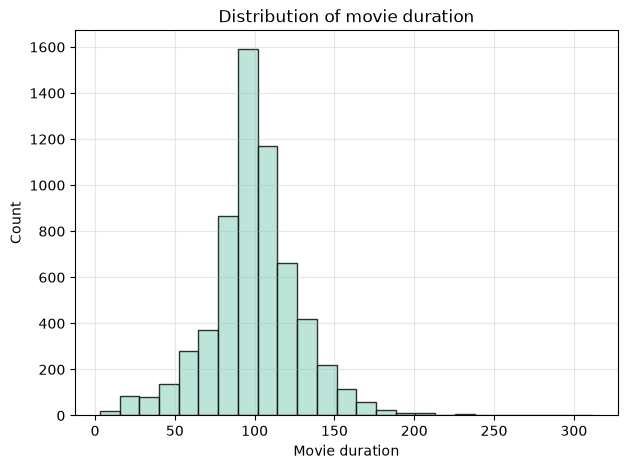

In [51]:
plt.figure(figsize=(7, 5))

plt.hist(movies['movie_duration_min'], bins=25, edgecolor='k', color = '#added0', alpha=0.8
)

plt.grid(alpha=0.3)

plt.title('Distribution of movie duration')
plt.xlabel('Movie duration')
plt.ylabel('Count')

plt.show()

In [42]:
movies["movie_duration_min"].skew()

np.float64(0.2025791123063926)

## 05. Number of TV shows seasons

In [75]:
tv_shows = df[(df['type'] == "tv_show") & df['tv_seasons'].notna()]
print(len(tv_shows))

2676


In [76]:
tv_seasons_sumarry = tv_shows['tv_seasons'].agg(['count', 'mean', 'median', 'min', 'max']).round(2)

tv_seasons_sumarry

count     2676.00
mean         1.76
median       1.00
min          1.00
max         17.00
Name: tv_seasons, dtype: float64

In [77]:
season_counts = (tv_shows["tv_seasons"].astype(int).value_count.sort_index())

season_counts

tv_seasons
1     1793
2      425
3      199
4       95
5       65
6       33
7       23
8       17
9        9
10       7
11       2
12       2
13       3
15       2
17       1
Name: count, dtype: int64

In [81]:
longest_tv_shows = (
    tv_shows[
        ["title","release_year","tv_seasons"]
    ]
    .sort_values(
        by="tv_seasons",
        ascending=False
    ).head(10)
)
longest_tv_shows.set_index('title')

,release_year,tv_seasons
title,,
grey's_anatomy,2020,17.0
supernatural,2019,15.0
ncis,2017,15.0
heartland,2019,13.0
comedians_of_the_world,2019,13.0
red_vs._blue,2015,13.0
trailer_park_boys,2018,12.0
criminal_minds,2017,12.0
frasier,2003,11.0
